## import libraries

In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

## Load Dataset

In [9]:
df = pd.read_excel("../data/Telco_customer_churn.xlsx")

df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")
df.dropna(inplace=True)

C:\Users\ishar\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


[[374]]
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       374

    accuracy                           1.00       374
   macro avg       1.00      1.00      1.00       374
weighted avg       1.00      1.00      1.00       374



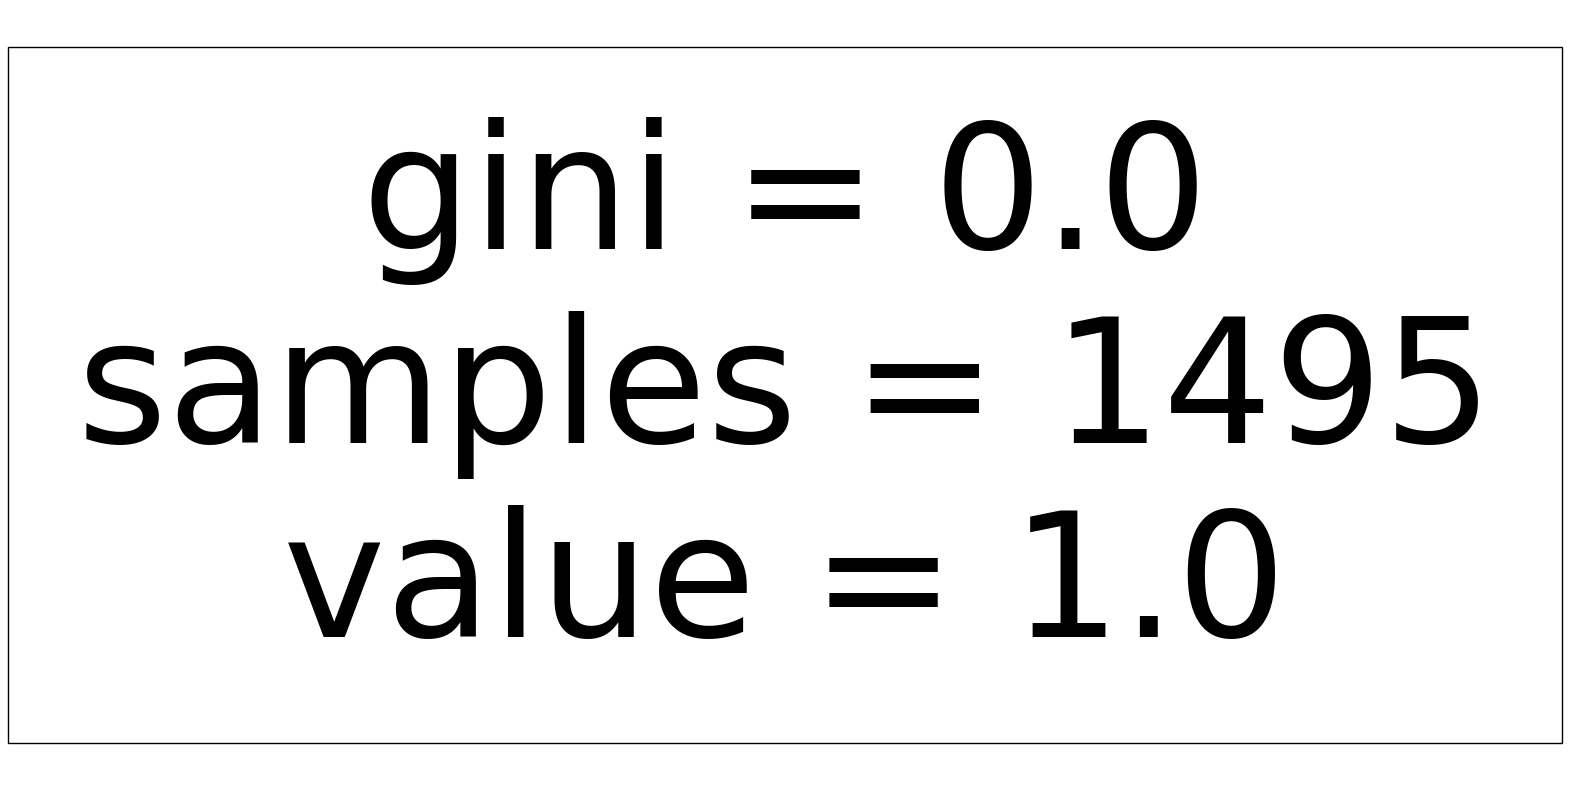

In [10]:
# Convert target
df["Churn"] = df["Churn Value"]

# One-hot encoding
df = pd.get_dummies(df.drop("CustomerID", axis=1), drop_first=True)

X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

model = DecisionTreeClassifier(max_depth=4)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Plot tree
plt.figure(figsize=(20,10))
plot_tree(model, max_depth=3, filled=True)
plt.show()